In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("data/azoseRaftery2019flows.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199000 entries, 0 to 198999
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   origin        199000 non-null  int64 
 1   destination   199000 non-null  int64 
 2   origIso       199000 non-null  object
 3   destIso       199000 non-null  object
 4   year          199000 non-null  int64 
 5   migrantCount  199000 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 9.1+ MB


In [4]:
df["migrantCount"].describe()

count    1.990000e+05
mean     1.932523e+03
std      2.509540e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.000000e+01
max      3.817502e+06
Name: migrantCount, dtype: float64

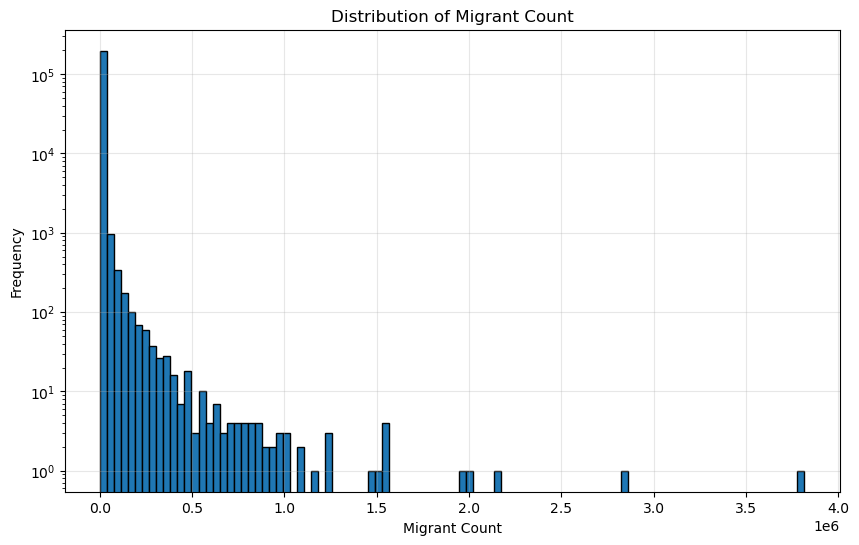

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(df["migrantCount"], bins=100, edgecolor='black')
plt.xlabel('Migrant Count')
plt.ylabel('Frequency')
plt.title('Distribution of Migrant Count')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
df["mij_normalized"] = df["migrantCount"] / df["migrantCount"].sum()

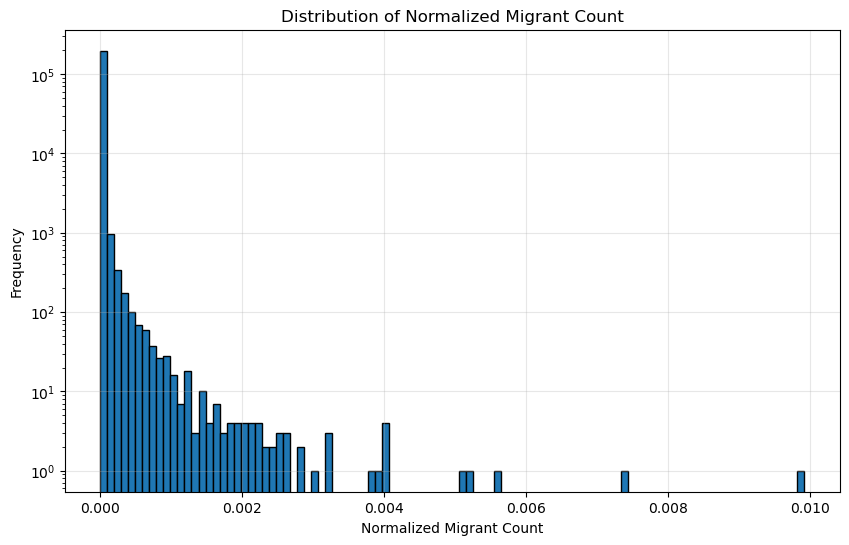

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(df["mij_normalized"], bins=100, edgecolor='black')
plt.xlabel('Normalized Migrant Count')
plt.ylabel('Frequency')
plt.title('Distribution of Normalized Migrant Count')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
from scipy.special import softmax

df["migrantCount_softmax"] = softmax(df["mij_normalized"])
df["migrantCount_softmax"].describe()

count    1.990000e+05
mean     5.025126e-06
std      3.284926e-10
min      5.025100e-06
25%      5.025100e-06
50%      5.025100e-06
75%      5.025101e-06
max      5.075231e-06
Name: migrantCount_softmax, dtype: float64

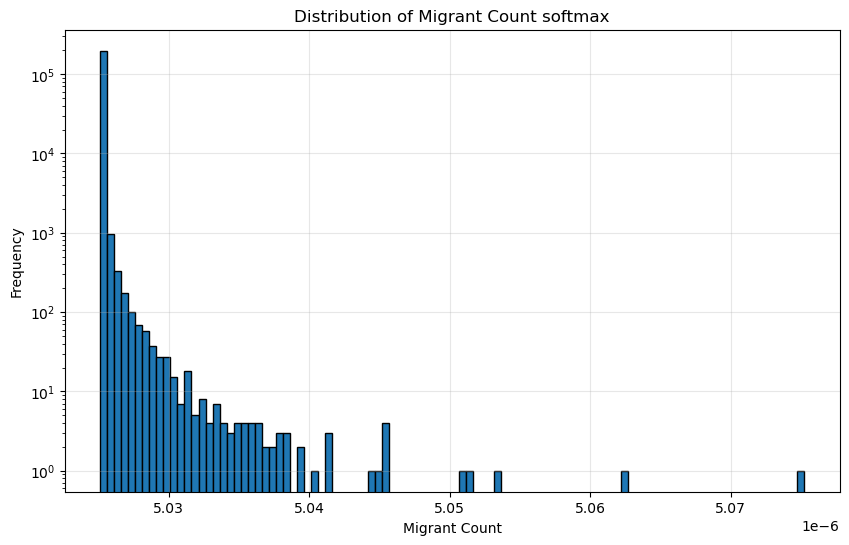

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df["migrantCount_softmax"], bins=100, edgecolor='black')
plt.xlabel('Migrant Count')
plt.ylabel('Frequency')
plt.title('Distribution of Migrant Count softmax')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

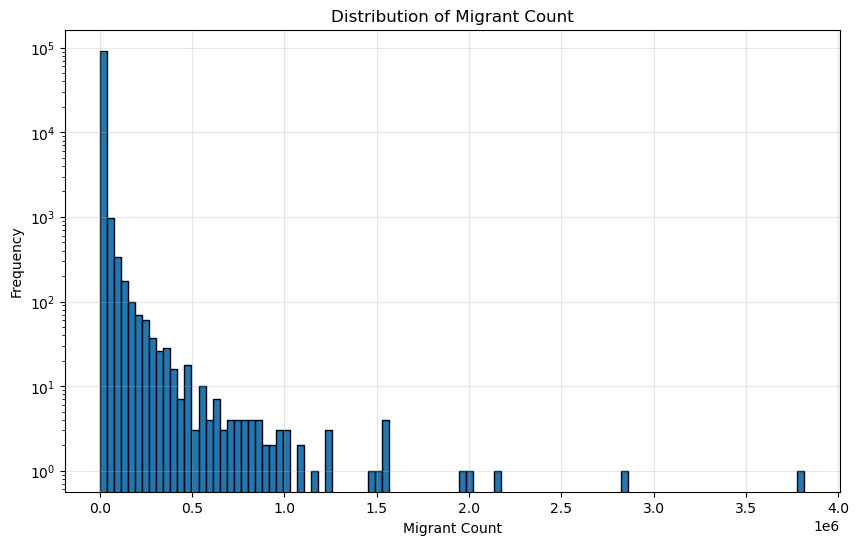

In [10]:
# Filter non-zero migrant counts
non_zero_mask = df["migrantCount"] > 0
non_zero_counts = df.loc[non_zero_mask, "migrantCount"]
plt.figure(figsize=(10, 6))
plt.hist(non_zero_counts, bins=100, edgecolor='black')
plt.xlabel('Migrant Count')
plt.ylabel('Frequency')
plt.title('Distribution of Migrant Count')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Calcul de pi_ijt = m_ijt / sum_{k != i} m_ikt
# Pour chaque origine i et temps t, on somme les flux vers toutes les destinations k != i
df["sum_mikt"] = df.groupby(["origIso", "year"])["migrantCount"].transform("sum")

# Calcul de pi_ijt (proportion des migrants de i vers j par rapport au total des sortants de i)
df["pi_ijt"] = df["migrantCount"] / df["sum_mikt"]

# Filtrer les cas où pi_ijt > 0 pour pouvoir prendre le log
df_nonzero = df[df["pi_ijt"] > 0].copy()

# Calcul de eta_lt = log(pi_ijt)
df_nonzero["eta_lt"] = np.log(df_nonzero["pi_ijt"])

print(f"Nombre d'observations avec pi_ijt > 0: {len(df_nonzero)}")
print(f"Statistiques de eta_lt (log(pi_ijt)):")
print(df_nonzero["eta_lt"].describe())

# Créer les indicatrices pour chaque couple (i, j)
df_nonzero["pair_ij"] = df_nonzero["origIso"] + "_" + df_nonzero["destIso"]

# APPROCHE RAPIDE: Au lieu d'OLS avec dummies, calculer directement la moyenne par paire
# Car dans le modèle eta_lt = k_ij * 1(l=(i,j)) + eps, k_ij = E[eta_lt | pair = (i,j)]
coefficients_df = df_nonzero.groupby("pair_ij").agg(
    k_ij=("eta_lt", "mean"),
    variance=("eta_lt", "var"),
    n_obs=("eta_lt", "count")
).reset_index()

# Fusionner pour calculer les résidus et R²
df_nonzero = df_nonzero.merge(coefficients_df[["pair_ij", "k_ij"]], on="pair_ij")
df_nonzero["eta_pred"] = df_nonzero["k_ij"]
df_nonzero["residual"] = df_nonzero["eta_lt"] - df_nonzero["eta_pred"]

# Calcul du R²
SS_res = (df_nonzero["residual"] ** 2).sum()
SS_tot = ((df_nonzero["eta_lt"] - df_nonzero["eta_lt"].mean()) ** 2).sum()
r2 = 1 - SS_res / SS_tot

print(f"\nNombre de paires (i,j) distinctes: {len(coefficients_df)}")
print(f"R² : {r2:.4f}")

# Estimation de psi_ij² (variance des résidus par paire)
coefficients_df = coefficients_df.sort_values("k_ij", ascending=False)
print(f"\nStatistiques des coefficients k_ij:")
print(coefficients_df["k_ij"].describe())

Nombre d'observations avec pi_ijt > 0: 94027
Statistiques de eta_lt (log(pi_ijt)):
count    94027.000000
mean        -8.206369
std          2.872271
min        -15.615351
25%        -10.374880
50%         -8.354204
75%         -6.210075
max         -0.018860
Name: eta_lt, dtype: float64

Nombre de paires (i,j) distinctes: 23607
R² : 0.9258

Statistiques des coefficients k_ij:
count    23607.000000
mean        -8.742798
std          2.811213
min        -15.615351
25%        -10.933619
50%         -9.006808
75%         -6.852906
max         -0.039557
Name: k_ij, dtype: float64


In [16]:
# Afficher les coefficients k_ij
print("Top 20 coefficients k_ij (plus grandes proportions de migration):")
print(coefficients_df[["pair_ij", "k_ij", "n_obs"]].head(20).to_string(index=False))

print("\n" + "="*60)
print("\nBottom 20 coefficients k_ij (plus petites proportions de migration):")
print(coefficients_df[["pair_ij", "k_ij", "n_obs"]].tail(20).to_string(index=False))

Top 20 coefficients k_ij (plus grandes proportions de migration):
pair_ij      k_ij  n_obs
MEX_USA -0.039557      5
ESH_DZA -0.039775      5
LSO_ZAF -0.044134      5
PRI_USA -0.090081      5
CUW_NLD -0.134490      5
SLV_USA -0.138847      5
SWZ_ZAF -0.161545      5
CLI_GBR -0.166982      5
GTM_USA -0.167199      5
BFA_CIV -0.214806      5
HND_USA -0.287427      5
TJK_RUS -0.298863      5
CUB_USA -0.321397      5
JAM_USA -0.344861      5
KGZ_RUS -0.354989      5
NAM_ZAF -0.417829      5
KAZ_RUS -0.420170      5
GNQ_GAB -0.422619      5
UKR_RUS -0.435624      5
TTO_USA -0.447078      5


Bottom 20 coefficients k_ij (plus petites proportions de migration):
pair_ij       k_ij  n_obs
CHN_MWI -15.006689      1
CHN_JAM -15.006689      1
CHN_SWZ -15.006689      1
IND_CPV -15.055125      3
IND_NER -15.139629      2
IND_GEO -15.195182      4
IND_MDA -15.195182      4
IND_KGZ -15.195182      4
MEX_COM -15.199657      1
MEX_SYC -15.199657      1
MEX_VUT -15.199657      1
MEX_MUS -15.199657      1


Top 20 corridors de migration (plus grandes proportions):
pair_ij      k_ij  pi_ij_percent  n_obs
MEX_USA -0.039557      96.121487      5
ESH_DZA -0.039775      96.100563      5
LSO_ZAF -0.044134      95.682565      5
PRI_USA -0.090081      91.385675      5
CUW_NLD -0.134490      87.416204      5
SLV_USA -0.138847      87.036149      5
SWZ_ZAF -0.161545      85.082844      5
CLI_GBR -0.166982      84.621495      5
GTM_USA -0.167199      84.603164      5
BFA_CIV -0.214806      80.669764      5
HND_USA -0.287427      75.019117      5
TJK_RUS -0.298863      74.166100      5
CUB_USA -0.321397      72.513563      5
JAM_USA -0.344861      70.831887      5
KGZ_RUS -0.354989      70.118139      5
NAM_ZAF -0.417829      65.847486      5
KAZ_RUS -0.420170      65.693540      5
GNQ_GAB -0.422619      65.532800      5
UKR_RUS -0.435624      64.686112      5
TTO_USA -0.447078      63.949432      5


<>:13: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:13: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/var/folders/nm/4_kf5v3s2zqdwj1f45p5q89r0000gn/T/ipykernel_21808/3400248764.py:13: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.title('Distribution des proportions de migration $\hat{\pi}_{ij}$')


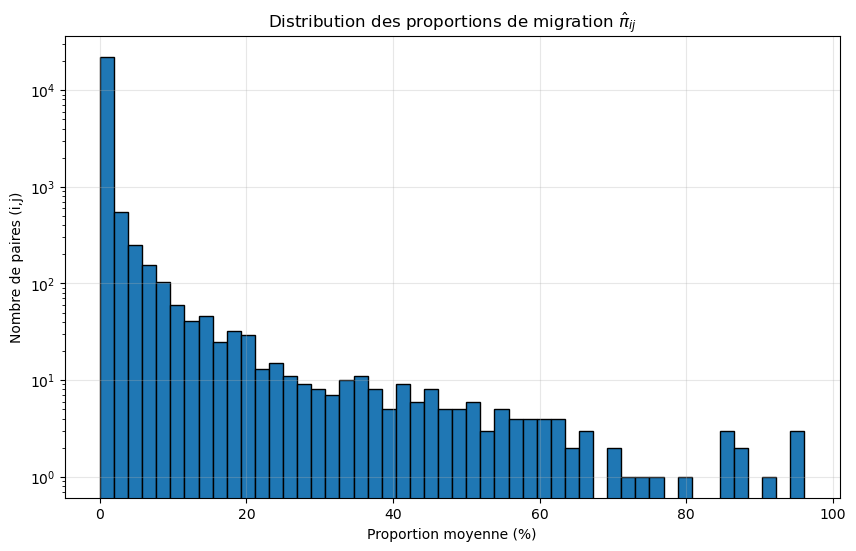

In [18]:
# Convertir k_ij en proportions pour une meilleure interprétation
coefficients_df["pi_ij_mean"] = np.exp(coefficients_df["k_ij"])
coefficients_df["pi_ij_percent"] = coefficients_df["pi_ij_mean"] * 100

print("Top 20 corridors de migration (plus grandes proportions):")
print(coefficients_df[["pair_ij", "k_ij", "pi_ij_percent", "n_obs"]].head(20).to_string(index=False))

# Histogramme des proportions
plt.figure(figsize=(10, 6))
plt.hist(coefficients_df["pi_ij_percent"], bins=50, edgecolor='black')
plt.xlabel('Proportion moyenne (%)')
plt.ylabel('Nombre de paires (i,j)')
plt.title('Distribution des proportions de migration $\hat{\pi}_{ij}$')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()